In [12]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



# Get metadata
metadata_url = "https://apiprod.dol.gov/v4/get/ETA/apprenticeship_data/json/metadata"
params = {"X-API-KEY":"t_fopy7FsrIHhnfHbBnitKefgK_wTfaqCEPs3ypttAU"}
metadata_request = requests.get(metadata_url, params=params, verify=False)
metadata_json = metadata_request.json()
metadata = pd.DataFrame(metadata_json)

# Get data 
data_url = "https://apiprod.dol.gov/v4/get/ETA/apprenticeship_data/json"
params = {"X-API-KEY":"t_fopy7FsrIHhnfHbBnitKefgK_wTfaqCEPs3ypttAU", "limit":"100"}
data_request = requests.get(data_url, params=params, verify=False)
data_json = data_request.json()['data']
data = pd.DataFrame(data_json)
print(data)


# Remove completely empty columns
data_clean = data.dropna(axis=1, how='all')

print("Cleaned columns:", list(data_clean.columns))
print("\\nFirst 5 rows:")
print(data_clean.head())



# Save to CSV
data_clean.to_csv('apprenticeship_data_cleaned.csv', index=False)

   fiscal_year table_name start_date exit_date apprentice_number  \
0         None       None       None      None              None   
1         None       None       None      None              None   
2         None       None       None      None              None   
3         None       None       None      None              None   
4         None       None       None      None              None   
..         ...        ...        ...       ...               ...   
95        None       None       None      None              None   
96        None       None       None      None              None   
97        None       None       None      None              None   
98        None       None       None      None              None   
99        None       None       None      None              None   

   program_number program_view naics_cd  union_y_n  apprentice_id  ...  \
0            None         None   238320        0.0        4852306  ...   
1            None         None   23

In [13]:
data_dict = data.to_dict()
print (data_dict)

{'fiscal_year': {0: None, 1: None, 2: None, 3: None, 4: None, 5: None, 6: None, 7: None, 8: None, 9: None, 10: None, 11: None, 12: None, 13: None, 14: None, 15: None, 16: None, 17: None, 18: None, 19: None, 20: None, 21: None, 22: None, 23: None, 24: None, 25: None, 26: None, 27: None, 28: None, 29: None, 30: None, 31: None, 32: None, 33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 48: None, 49: None, 50: None, 51: None, 52: None, 53: None, 54: None, 55: None, 56: None, 57: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 65: None, 66: None, 67: None, 68: None, 69: None, 70: None, 71: None, 72: None, 73: None, 74: None, 75: None, 76: None, 77: None, 78: None, 79: None, 80: None, 81: None, 82: None, 83: None, 84: None, 85: None, 86: None, 87: None, 88: None, 89: None, 90: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 97: None, 98: None, 99:

In [14]:
data.columns = data.columns.str.lower().str.replace(" ", "_")
print(data.columns)

Index(['fiscal_year', 'table_name', 'start_date', 'exit_date',
       'apprentice_number', 'program_number', 'program_view', 'naics_cd',
       'union_y_n', 'apprentice_id', 'age_cohort', 'ethnicity', 'gender',
       'race', 'veteran_status_title', 'individuals_with_disabilities',
       'industry', 'occupation', 'education', 'apprentice_status_code',
       'active_adjust', 'completer_adjust', 'exit_wage_adjust', 'new_adjust',
       'start_wage_adjust', 'hud_state', 'county_fips', 'county_name', 'state',
       'appr_state', 'appr_county_fips', 'appr_county_name', 'starting_wage',
       'exit_wage'],
      dtype='object')


In [15]:

print(type(data))
print(type(data_clean))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [16]:
print(data.shape)

(100, 34)


In [17]:
print(data.head())

  fiscal_year table_name start_date exit_date apprentice_number  \
0        None       None       None      None              None   
1        None       None       None      None              None   
2        None       None       None      None              None   
3        None       None       None      None              None   
4        None       None       None      None              None   

  program_number program_view naics_cd  union_y_n  apprentice_id  ...  \
0           None         None   238320        0.0        4852306  ...   
1           None         None   238220        1.0        4852732  ...   
2           None         None   722511        0.0        4852983  ...   
3           None         None   623110        0.0        4853422  ...   
4           None         None   238320        1.0        4125928  ...   

  start_wage_adjust hud_state county_fips county_name state appr_state  \
0             18.75        CA        None        None    CA         CA   
1         

In [19]:
# Defining the NAICS mappings 

NAICS_SECTORS = {
    '11': 'Agriculture, Forestry, Fishing and Hunting',
    '21': 'Mining, Quarrying, and Oil and Gas Extraction',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44': 'Retail Trade',
    '45': 'Retail Trade',
    '48': 'Transportation and Warehousing',
    '49': 'Transportation and Warehousing',
    '51': 'Information',
    '52': 'Finance and Insurance',
    '53': 'Real Estate and Rental and Leasing',
    '54': 'Professional, Scientific, and Technical Services',
    '55': 'Management of Companies and Enterprises',
    '56': 'Administrative and Support Services',
    '61': 'Educational Services',
    '62': 'Health Care and Social Assistance',
    '71': 'Arts, Entertainment, and Recreation',
    '72': 'Accommodation and Food Services',
    '81': 'Other Services (except Public Administration)',
    '92': 'Public Administration'
}

# Common 3-digit subsectors for more detail
NAICS_SUBSECTORS = {
    '236': 'Construction - Building Construction',
    '237': 'Construction - Heavy and Civil Engineering',
    '238': 'Construction - Specialty Trade Contractors',
    '311': 'Food Manufacturing',
    '323': 'Printing and Related Support',
    '326': 'Plastics and Rubber Products',
    '331': 'Primary Metal Manufacturing',
    '332': 'Fabricated Metal Product Manufacturing',
    '333': 'Machinery Manufacturing',
    '335': 'Electrical Equipment Manufacturing',
    '336': 'Transportation Equipment Manufacturing',
    '423': 'Merchant Wholesalers - Durable Goods',
    '441': 'Motor Vehicle and Parts Dealers',
    '484': 'Truck Transportation',
    '621': 'Ambulatory Health Care Services',
    '622': 'Hospitals',
    '623': 'Nursing and Residential Care',
    '722': 'Food Services and Drinking Places',
    '811': 'Repair and Maintenance'
}


print("Preparing NAICS classifications...")

# Ensure naics_cd is string
data['naics_cd'] = data['naics_cd'].astype(str)

# Extract 2-digit sector code
data['naics_2digit'] = data['naics_cd'].str[:2]

# Extract 3-digit subsector code
data['naics_3digit'] = data['naics_cd'].str[:3]

# Map to sector names
data['sector'] = data['naics_2digit'].map(NAICS_SECTORS)
data['sector'] = data['sector'].fillna('Other/Unknown')

# Map to subsector names (where available)
data['subsector'] = data['naics_3digit'].map(NAICS_SUBSECTORS)

print("✓ NAICS columns created!")

# Verify the results
print("\n" + "="*70)
print("VERIFICATION")
print("="*70)

# Show sector distribution
print("\nTop 5 Sectors:")
print(data['sector'].value_counts().head())

# Show subsector distribution
print("\nTop 5 Subsectors:")
print(data['subsector'].value_counts().head())

# Check for any missing mappings
unmapped = data[data['sector'] == 'Other/Unknown']
if len(unmapped) > 0:
    print(f"\n⚠️  {len(unmapped)} records have unmapped NAICS codes:")
    print(unmapped['naics_2digit'].value_counts().head())
else:
    print("\n✓ All records mapped successfully!")

Preparing NAICS classifications...
✓ NAICS columns created!

VERIFICATION

Top 5 Sectors:
sector
Construction                         37
Public Administration                32
Health Care and Social Assistance     6
Other/Unknown                         6
Educational Services                  5
Name: count, dtype: int64

Top 5 Subsectors:
subsector
Construction - Specialty Trade Contractors    28
Construction - Building Construction           6
Construction - Heavy and Civil Engineering     3
Hospitals                                      3
Food Services and Drinking Places              1
Name: count, dtype: int64

⚠️  6 records have unmapped NAICS codes:
naics_2digit
No    6
Name: count, dtype: int64


In [23]:
NAICS_SUBSECTORS = {
    '236': 'Construction - Building Construction',
    '237': 'Construction - Heavy and Civil Engineering',
    '238': 'Construction - Specialty Trade Contractors',
    '311': 'Food Manufacturing',
    '323': 'Printing and Related Support',
    '326': 'Plastics and Rubber Products',
    '331': 'Primary Metal Manufacturing',
    '332': 'Fabricated Metal Product Manufacturing',
    '333': 'Machinery Manufacturing',
    '335': 'Electrical Equipment Manufacturing',
    '336': 'Transportation Equipment Manufacturing',
    '423': 'Merchant Wholesalers - Durable Goods',
    '441': 'Motor Vehicle and Parts Dealers',
    '484': 'Truck Transportation',
    '621': 'Ambulatory Health Care Services',
    '622': 'Hospitals',
    '623': 'Nursing and Residential Care',
    '722': 'Food Services and Drinking Places',
    '811': 'Repair and Maintenance'
}


def analyze_by_subsector(data_clean):
    """
    Detailed analysis by subsector (3-digit NAICS)
    """
    
    print("\n" + "="*70)
    print("SUBSECTOR ANALYSIS (3-DIGIT NAICS)")
    print("="*70)
    
    # Count by 3-digit code
    subsector_counts = data_clean['naics_3digit'].value_counts().sort_values(ascending=False).head(20)
    
    # Create detailed table
    subsector_data = []
    for code, count in subsector_counts.items():
        name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
        pct = (count / len(data_clean) * 100)
        subsector_data.append({
            'NAICS Code': code,
            'Subsector': name,
            'Apprentices': count,
            'Percentage': round(pct, 2)
        })
    
    subsector_df = pd.DataFrame(subsector_data)
    
    print("\nTop 20 Subsectors by Apprentice Count:")
    print("-"*70)
    print(subsector_df.to_string(index=False))
    
    return subsector_df

# STEP 2: CREATE naics_3digit COLUMN (if it doesn't exist)
if 'naics_3digit' not in data_clean.columns:
    print("Creating naics_3digit column...")
    data_clean['naics_cd'] = data_clean['naics_cd'].astype(str)
    data_clean['naics_3digit'] = data_clean['naics_cd'].str[:3]
    print("✓ Column created!")
    print(f"Sample values: {data_clean['naics_3digit'].head().tolist()}")

# STEP 3: NOW RUN THE ANALYSIS
subsector_results = analyze_by_subsector(data_clean)

# STEP 4: Display results
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"\nTop subsector: {subsector_results.iloc[0]['Subsector']}")
print(f"Count: {subsector_results.iloc[0]['Apprentices']:,}")
print(f"Share: {subsector_results.iloc[0]['Percentage']:.1f}%")

# Export to Excel
subsector_results.to_excel('subsector_analysis.xlsx', index=False)
print("\n✓ Results saved to subsector_analysis.xlsx")


SUBSECTOR ANALYSIS (3-DIGIT NAICS)

Top 20 Subsectors by Apprentice Count:
----------------------------------------------------------------------
NAICS Code                                  Subsector  Apprentices  Percentage
       238 Construction - Specialty Trade Contractors           28        28.0
       928                                  NAICS 928           26        26.0
       236       Construction - Building Construction            6         6.0
       922                                  NAICS 922            6         6.0
       Non                                  NAICS Non            6         6.0
       611                                  NAICS 611            5         5.0
       221                                  NAICS 221            5         5.0
       237 Construction - Heavy and Civil Engineering            3         3.0
       622                                  Hospitals            3         3.0
       812                                  NAICS 812          

In [24]:

def analyze_by_subsector(data_clean):
    """
    Detailed analysis by subsector (3-digit NAICS)
    """
    
    print("\\n" + "="*70)
    print("SUBSECTOR ANALYSIS (3-DIGIT NAICS)")
    print("="*70)
    
    # Count by 3-digit code
    subsector_counts = data_clean['naics_3digit'].value_counts().sort_values(ascending=False).head(20)
    
    # Create detailed table
    subsector_data = []
    for code, count in subsector_counts.items():
        name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
        pct = (count / len(data_clean) * 100)  
        subsector_data.append({
            'NAICS Code': code,
            'Subsector': name,
            'Apprentices': count,
            'Percentage': round(pct, 2)
        })
    
    subsector_df = pd.DataFrame(subsector_data) 
    
    print("\\nTop 20 Subsectors by Apprentice Count:")
    print("-"*70)
    print(subsector_df.to_string(index=False))
    
    return subsector_df  

if 'naics_3digit' not in data_clean.columns:
    print("Creating naics_3digit column...")
    data_clean['naics_cd'] = data_clean['naics_cd'].astype(str)
    data_clean['naics_3digit'] = data_clean['naics_cd'].str[:3]
    print("✓ Column created!")
    
results = analyze_by_subsector(data_clean)
    


print("\\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Top subsector: {results.iloc[0]['Subsector']}")
print(f"Apprentices: {results.iloc[0]['Apprentices']:,}")
print(f"Market share: {results.iloc[0]['Percentage']:.1f}%")

\n======================================================================
SUBSECTOR ANALYSIS (3-DIGIT NAICS)
\nTop 20 Subsectors by Apprentice Count:
----------------------------------------------------------------------
NAICS Code                                  Subsector  Apprentices  Percentage
       238 Construction - Specialty Trade Contractors           28        28.0
       928                                  NAICS 928           26        26.0
       236       Construction - Building Construction            6         6.0
       922                                  NAICS 922            6         6.0
       Non                                  NAICS Non            6         6.0
       611                                  NAICS 611            5         5.0
       221                                  NAICS 221            5         5.0
       237 Construction - Heavy and Civil Engineering            3         3.0
       622                                  Hospitals            3   

\n======================================================================
TOP 20 SPECIFIC NAICS CODES
\nTop 20 NAICS Codes with Industry and Occupation:
----------------------------------------------------------------------
\nNAICS 928110:
  Industry: Public Administration (not covered in economic census)
  Occupation: Not Provided
  Apprentices: 25
\nNAICS None:
  Industry: Not Provided
  Occupation: Not Provided
  Apprentices: 6
\nNAICS 238210:
  Industry: Construction
  Occupation: ELECTRICIAN (Alternate Title: Interior Electrician)
  Apprentices: 6
\nNAICS 238220:
  Industry: Construction
  Occupation: HEATING & AIR-CONDITIONER INSTALL/SER
  Apprentices: 4
\nNAICS 922160:
  Industry: Public Administration (not covered in economic census)
  Occupation: Not Provided
  Apprentices: 3
\nNAICS 238350:
  Industry: Construction
  Occupation: CARPENTER
  Apprentices: 3
\nNAICS 622110:
  Industry: Health Care and Social Assistance
  Occupation: Registered Nurse Resident
  Apprentices: 3
\nNA

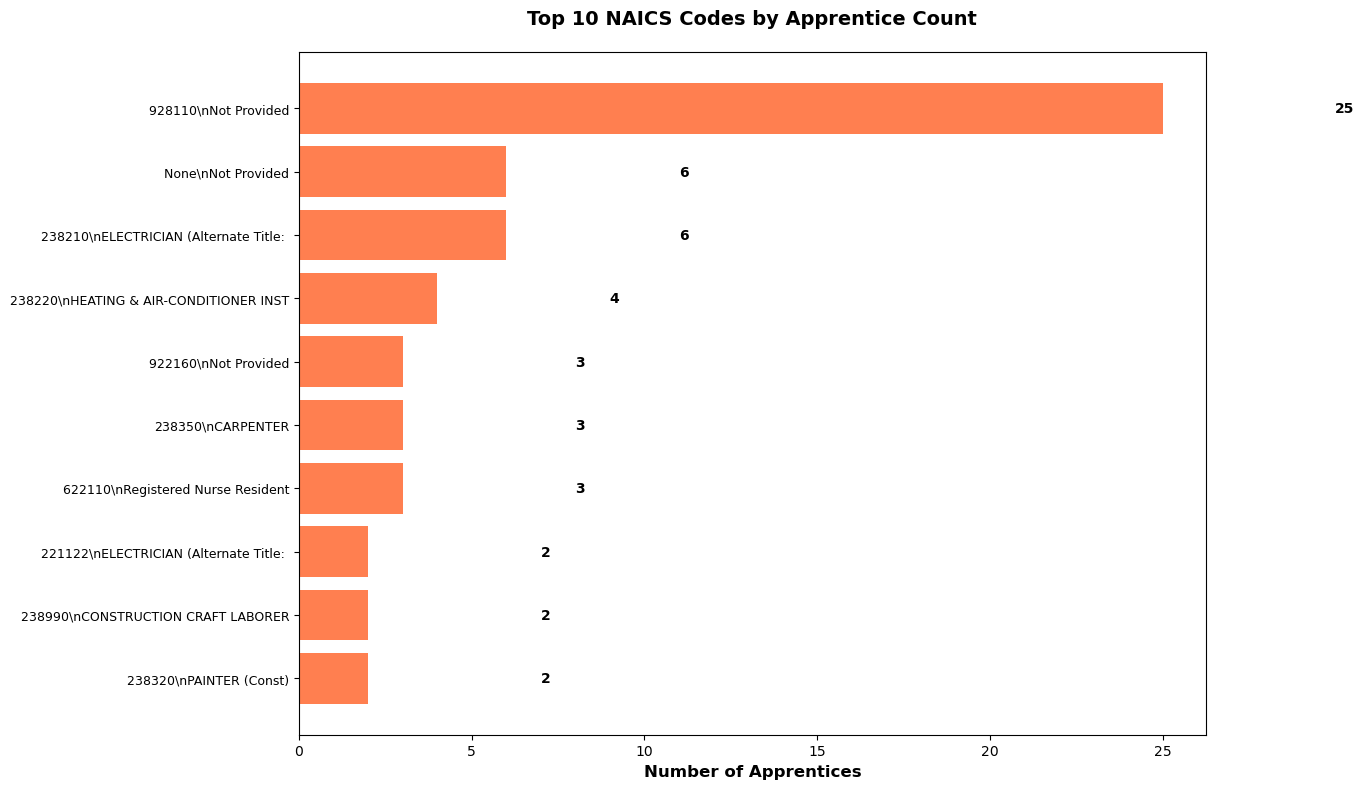

✓ Chart saved: top_naics_codes.png


In [25]:

import pandas as pd

def analyze_specific_naics_codes(data_clean, top_n=30):
    """
    Analyze specific 6-digit NAICS codes
    """
    
    print("\\n" + "="*70)
    print(f"TOP {top_n} SPECIFIC NAICS CODES")
    print("="*70)
    
    # Count by full NAICS code
    naics_counts = data_clean.groupby(['naics_cd', 'industry', 'occupation']).size().reset_index(name='count')
    naics_counts = naics_counts.sort_values('count', ascending=False).head(top_n)
    
    print(f"\\nTop {top_n} NAICS Codes with Industry and Occupation:")
    print("-"*70)
    
    for idx, row in naics_counts.iterrows():
        print(f"\\nNAICS {row['naics_cd']}:")
        print(f"  Industry: {row['industry']}")
        print(f"  Occupation: {row['occupation']}")
        print(f"  Apprentices: {row['count']:,}")
    
    return naics_counts

# Run the analysis
top_naics = analyze_specific_naics_codes(data_clean, top_n=20)

# Display as table too
print("\\n" + "="*70)
print("TABLE VIEW")
print("="*70)
print(top_naics.to_string(index=False))

# Export to Excel
top_naics.to_excel('top_naics_codes.xlsx', index=False)
print("\\n✓ Saved to: top_naics_codes.xlsx")

top_10 = top_naics.head(10)

fig, ax = plt.subplots(figsize=(14, 8))

# Create labels combining NAICS + occupation
labels = [f"{row['naics_cd']}\\n{row['occupation'][:30]}" for _, row in top_10.iterrows()]

bars = ax.barh(range(len(top_10)), top_10['count'], color='coral')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
ax.set_title('Top 10 NAICS Codes by Apprentice Count', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add value labels
for i, val in enumerate(top_10['count']):
    ax.text(val + 5, i, f'{val:,}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('top_naics_codes.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved: top_naics_codes.png")


In [26]:

def cross_sector_analysis(data_clean):
    """
    Compare sectors across multiple dimensions
    """
    
    print("\\n" + "="*70)
    print("CROSS-SECTOR COMPARATIVE ANALYSIS")
    print("="*70)
    
    analysis_data = []
    
    for sector in data_clean['sector'].value_counts().head(10).index:
        sector_df = data_clean[data_clean['sector'] == sector]
        
        analysis_data.append({
            'Sector': sector,
            'Total Apprentices': len(sector_df),
            'Union Rate (%)': round(sector_df['union_y_n'].mean() * 100, 1) if 'union_y_n' in data_clean.columns else None,
            'Avg Start Wage ($)': round(sector_df['starting_wage'].mean(), 2) if 'starting_wage' in data_clean.columns else None,
            '% Female': round((sector_df['gender'] == 'Female').sum() / len(sector_df) * 100, 1) if 'gender' in data_clean.columns else None,
            'Unique Occupations': sector_df['occupation'].nunique() if 'occupation' in data_clean.columns else None
        })
    
    comparison_df = pd.DataFrame(analysis_data)
    
    print("\\nSector Comparison (Top 10):")
    print("-"*70)
    print(comparison_df.to_string(index=False))
    
    return comparison_df

# Make sure 'sector' column exists first
if 'sector' not in data_clean.columns:
    print("Creating sector column...")
    data_clean['naics_cd'] = data_clean['naics_cd'].astype(str)
    data_clean['naics_2digit'] = data_clean['naics_cd'].str[:2]
    
    NAICS_SECTORS = {
        '23': 'Construction',
        '31': 'Manufacturing', '32': 'Manufacturing', '33': 'Manufacturing',
        '42': 'Wholesale Trade',
        '44': 'Retail Trade', '45': 'Retail Trade',
        '48': 'Transportation and Warehousing', '49': 'Transportation and Warehousing',
        '62': 'Health Care and Social Assistance',
        '72': 'Accommodation and Food Services',
        '81': 'Other Services',
    }
    
    data_clean['sector'] = data_clean['naics_2digit'].map(NAICS_SECTORS)
    data_clean['sector'] = data_clean['sector'].fillna('Other/Unknown')
    print("✓ Sector column created!")

# Run the analysis
comparison_results = cross_sector_analysis(data_clean)

# Display key insights
print("\\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Sector with highest union rate
if 'Union Rate (%)' in comparison_results.columns:
    top_union = comparison_results.nlargest(1, 'Union Rate (%)')
    print(f"\\nHighest Union Rate: {top_union.iloc[0]['Sector']}")
    print(f"  Rate: {top_union.iloc[0]['Union Rate (%)']}%")

# Sector with highest wages
if 'Avg Start Wage ($)' in comparison_results.columns:
    top_wage = comparison_results.nlargest(1, 'Avg Start Wage ($)')
    print(f"\\nHighest Average Starting Wage: {top_wage.iloc[0]['Sector']}")
    print(f"  Wage: ${top_wage.iloc[0]['Avg Start Wage ($)']:,.2f}")

# Sector with most gender diversity
if '% Female' in comparison_results.columns:
    top_female = comparison_results.nlargest(1, '% Female')
    print(f"\\nHighest Female Participation: {top_female.iloc[0]['Sector']}")
    print(f"  Percentage: {top_female.iloc[0]['% Female']}%")

# Export to Excel
comparison_results.to_excel('sector_comparison.xlsx', index=False)
print("\\n✓ Results saved to: sector_comparison.xlsx")



Creating sector column...
✓ Sector column created!
\n======================================================================
CROSS-SECTOR COMPARATIVE ANALYSIS
\nSector Comparison (Top 10):
----------------------------------------------------------------------
                           Sector  Total Apprentices  Union Rate (%)  Avg Start Wage ($)  % Female  Unique Occupations
                    Other/Unknown                 50            37.0               17.66      16.0                  13
                     Construction                 37            67.6               21.12       2.7                  18
Health Care and Social Assistance                  6             0.0               26.19      83.3                   4
                   Other Services                  3             0.0               13.33      33.3                   2
                    Manufacturing                  2            50.0               23.38       0.0                   2
  Accommodation and Food Se

PREPARING DATA
✓ NAICS columns created!

CREATING SECTOR SUMMARY
✓ Sector summary created!

Top 5 Sectors:
                              Sector  Apprentices  Percentage
0                       Construction           37        37.0
1              Public Administration           32        32.0
2  Health Care and Social Assistance            6         6.0
3                      Other/Unknown            6         6.0
4               Educational Services            5         5.0

CREATING SECTOR STATS WITH UNION RATES
✓ Sector stats created!

CREATING VISUALIZATIONS
✓ Saved: naics_top_sectors.png


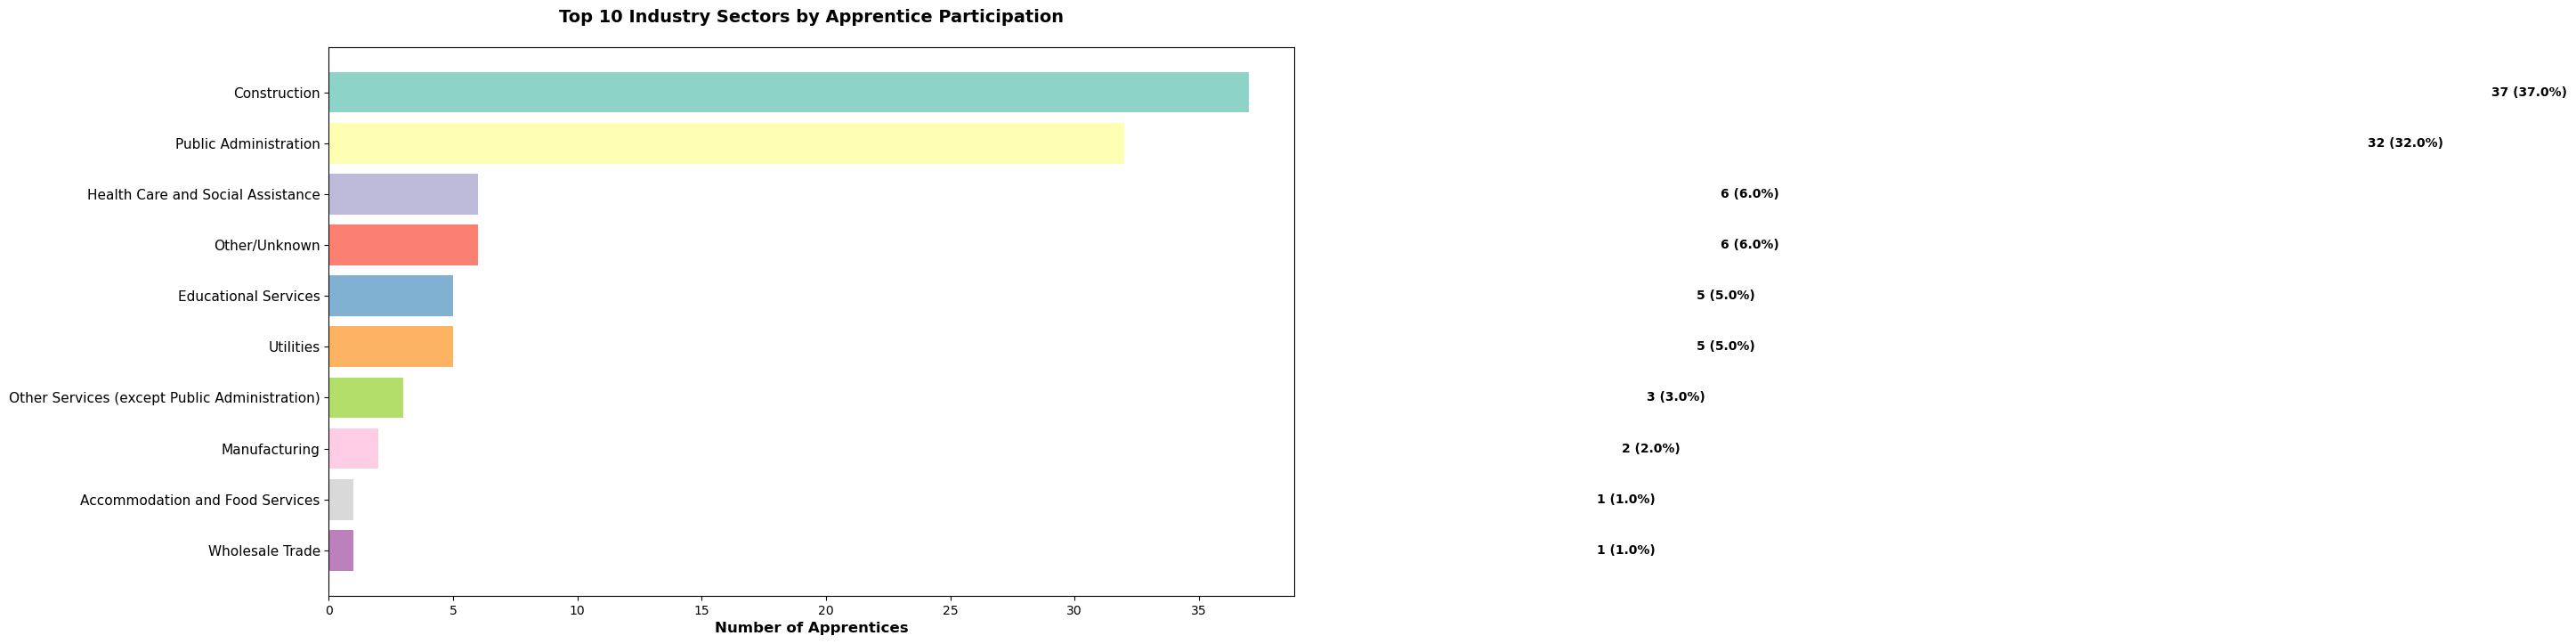

✓ Saved: naics_sector_pie.png


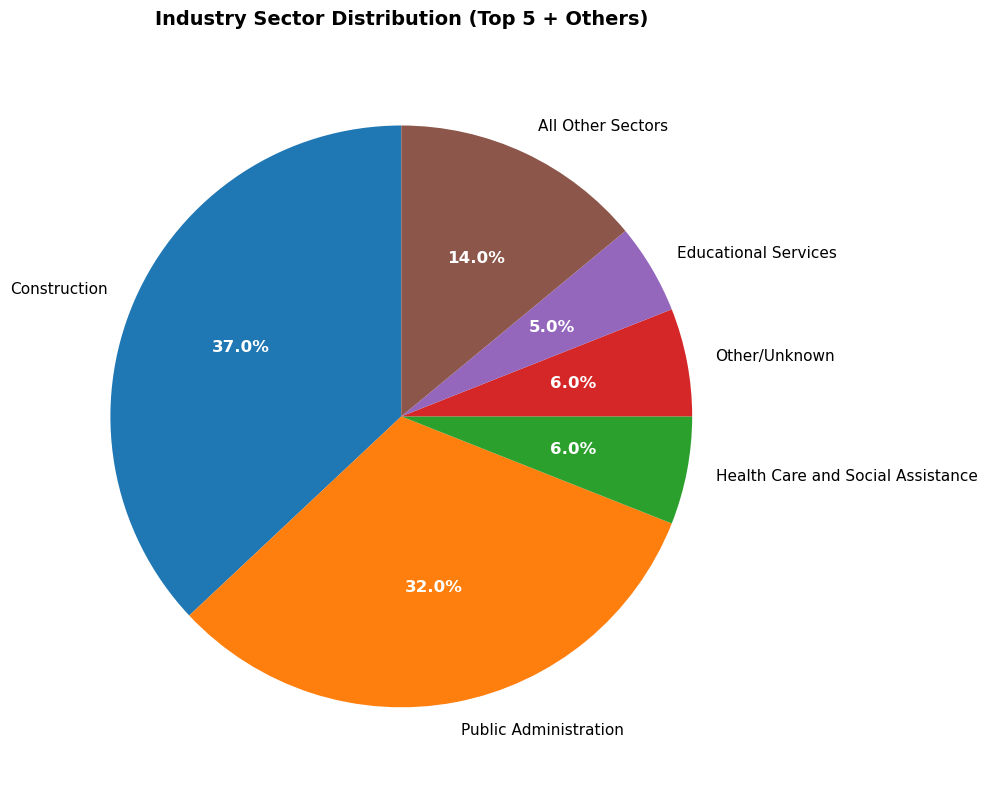

✓ Saved: naics_sector_union_comparison.png


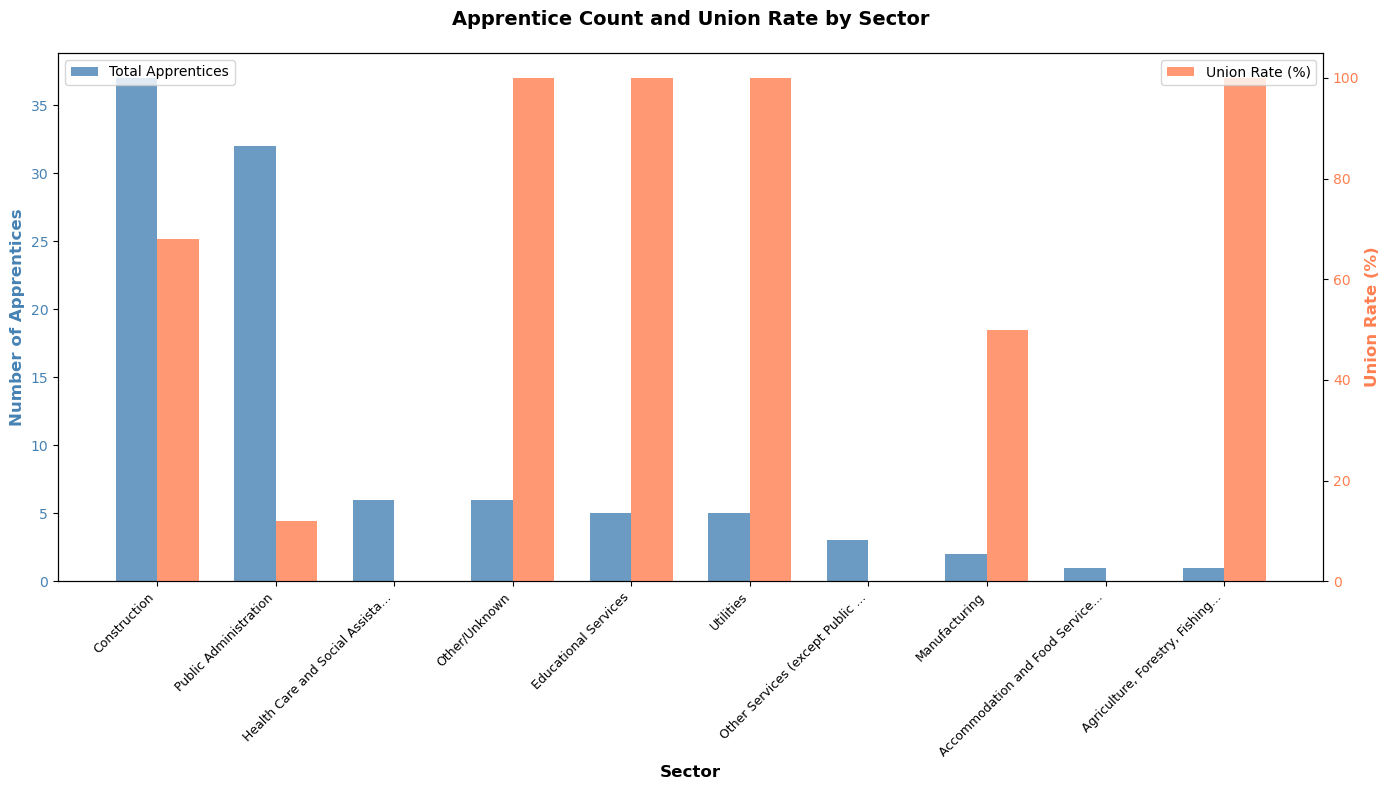

✓ Saved: naics_subsectors.png


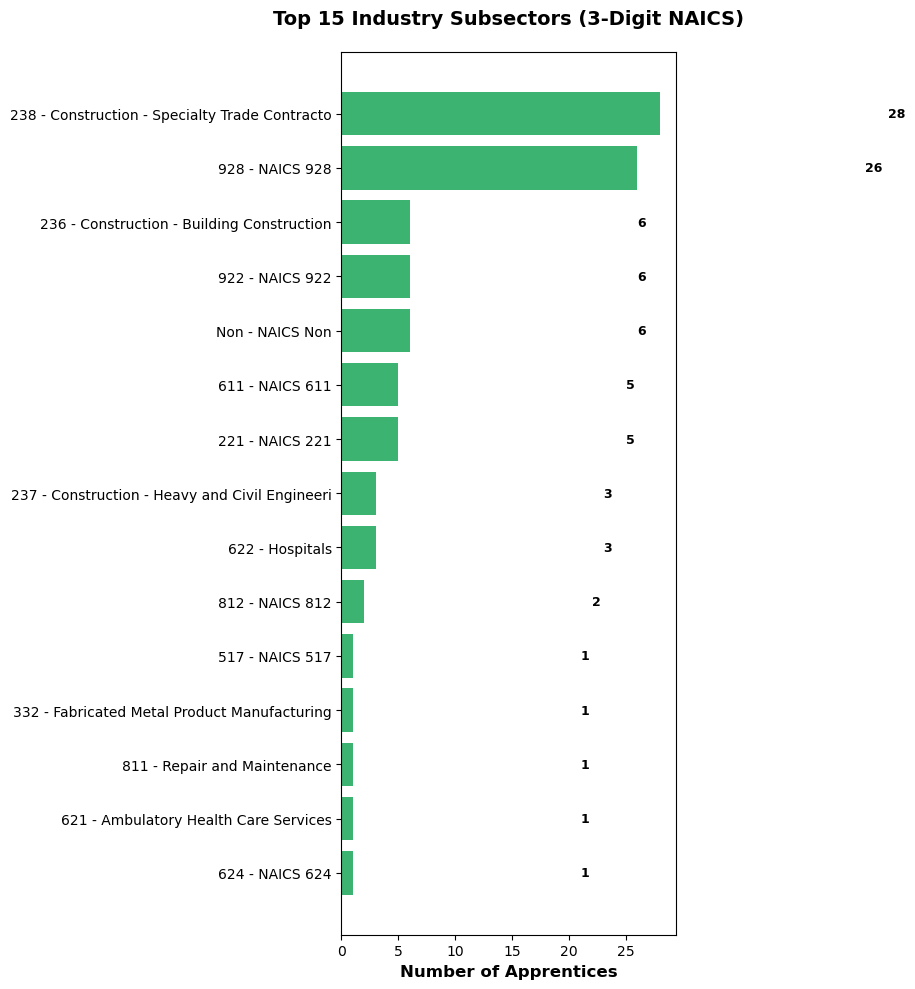


ALL VISUALIZATIONS COMPLETE


In [28]:
NAICS_SECTORS = {
    '11': 'Agriculture, Forestry, Fishing and Hunting',
    '21': 'Mining, Quarrying, and Oil and Gas Extraction',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44': 'Retail Trade',
    '45': 'Retail Trade',
    '48': 'Transportation and Warehousing',
    '49': 'Transportation and Warehousing',
    '51': 'Information',
    '52': 'Finance and Insurance',
    '53': 'Real Estate and Rental and Leasing',
    '54': 'Professional, Scientific, and Technical Services',
    '55': 'Management of Companies and Enterprises',
    '56': 'Administrative and Support Services',
    '61': 'Educational Services',
    '62': 'Health Care and Social Assistance',
    '71': 'Arts, Entertainment, and Recreation',
    '72': 'Accommodation and Food Services',
    '81': 'Other Services (except Public Administration)',
    '92': 'Public Administration'
}

# STEP 1: Prepare NAICS columns
print("="*70)
print("PREPARING DATA")
print("="*70)

data_clean['naics_cd'] = data_clean['naics_cd'].astype(str)
data_clean['naics_2digit'] = data_clean['naics_cd'].str[:2]
data_clean['naics_3digit'] = data_clean['naics_cd'].str[:3]

# Map to sector names
data_clean['sector'] = data_clean['naics_2digit'].map(NAICS_SECTORS)
data_clean['sector'] = data_clean['sector'].fillna('Other/Unknown')

print("✓ NAICS columns created!")

# STEP 2: Create sector_summary
print("\n" + "="*70)
print("CREATING SECTOR SUMMARY")
print("="*70)

sector_counts = data_clean['sector'].value_counts().sort_values(ascending=False)
sector_pct = (sector_counts / len(data_clean) * 100).round(2)

sector_summary = pd.DataFrame({
    'Sector': sector_counts.index,
    'Apprentices': sector_counts.values,
    'Percentage': sector_pct.values
})

print("✓ Sector summary created!")
print("\nTop 5 Sectors:")
print(sector_summary.head())

# STEP 3: Create sector_stats (optional - with union rates)
sector_stats = None
if 'union_y_n' in data_clean.columns:
    print("\n" + "="*70)
    print("CREATING SECTOR STATS WITH UNION RATES")
    print("="*70)
    
    sector_stats = data_clean.groupby('sector').agg({
        'apprentice_id': 'count',
        'union_y_n': 'mean',
        'starting_wage': 'mean' if 'starting_wage' in data_clean.columns else 'count'
    }).round(2)
    
    sector_stats.columns = ['Count', 'Union Rate', 'Avg Start Wage']
    sector_stats = sector_stats.sort_values('Count', ascending=False)
    
    print("✓ Sector stats created!")

# STEP 4: Define the visualization function
def create_naics_visualizations(data_clean, sector_summary, sector_stats=None):
    """
    Create comprehensive visualizations for NAICS analysis
    """
    
    print("\n" + "="*70)
    print("CREATING VISUALIZATIONS")
    print("="*70)
    
    # Figure 1: Top Sectors Bar Chart
    fig1, ax1 = plt.subplots(figsize=(14, 8))
    
    top_10 = sector_summary.head(10)
    colors = plt.cm.Set3(range(len(top_10)))
    
    bars = ax1.barh(range(len(top_10)), top_10['Apprentices'], color=colors)
    ax1.set_yticks(range(len(top_10)))
    ax1.set_yticklabels(top_10['Sector'], fontsize=11)
    ax1.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
    ax1.set_title('Top 10 Industry Sectors by Apprentice Participation', 
                  fontsize=14, fontweight='bold', pad=20)
    ax1.invert_yaxis()
    
    # Add value labels
    for i, (bar, val, pct) in enumerate(zip(bars, top_10['Apprentices'], top_10['Percentage'])):
        ax1.text(val + 50, i, f'{val:,} ({pct:.1f}%)', 
                va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('naics_top_sectors.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: naics_top_sectors.png")
    plt.show()
    
    # Figure 2: Sector Distribution Pie Chart
    fig2, ax2 = plt.subplots(figsize=(12, 8))
    
    top_5 = sector_summary.head(5)
    other_count = sector_summary['Apprentices'][5:].sum()
    
    pie_data = list(top_5['Apprentices']) + [other_count]
    pie_labels = list(top_5['Sector']) + ['All Other Sectors']
    
    wedges, texts, autotexts = ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                        startangle=90, textprops={'fontsize': 11})
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    
    ax2.set_title('Industry Sector Distribution (Top 5 + Others)', 
                  fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('naics_sector_pie.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: naics_sector_pie.png")
    plt.show()
    
    # Figure 3: Union Rate by Sector (if available)
    if sector_stats is not None and 'Union Rate' in sector_stats.columns:
        fig3, ax3 = plt.subplots(figsize=(14, 8))
        
        top_sectors = sector_stats.head(10)
        
        x = np.arange(len(top_sectors))
        width = 0.35
        
        # Plot counts and union rates
        ax3_twin = ax3.twinx()
        
        bars1 = ax3.bar(x - width/2, top_sectors['Count'], width, 
                       label='Total Apprentices', color='steelblue', alpha=0.8)
        bars2 = ax3_twin.bar(x + width/2, top_sectors['Union Rate'] * 100, width,
                            label='Union Rate (%)', color='coral', alpha=0.8)
        
        ax3.set_xlabel('Sector', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Number of Apprentices', fontsize=12, fontweight='bold', color='steelblue')
        ax3_twin.set_ylabel('Union Rate (%)', fontsize=12, fontweight='bold', color='coral')
        ax3.set_title('Apprentice Count and Union Rate by Sector', 
                     fontsize=14, fontweight='bold', pad=20)
        
        ax3.set_xticks(x)
        ax3.set_xticklabels([s[:30] + '...' if len(s) > 30 else s 
                            for s in top_sectors.index], rotation=45, ha='right', fontsize=9)
        
        ax3.legend(loc='upper left')
        ax3_twin.legend(loc='upper right')
        
        ax3.tick_params(axis='y', labelcolor='steelblue')
        ax3_twin.tick_params(axis='y', labelcolor='coral')
        
        plt.tight_layout()
        plt.savefig('naics_sector_union_comparison.png', dpi=300, bbox_inches='tight')
        print("✓ Saved: naics_sector_union_comparison.png")
        plt.show()
    
    # Figure 4: 3-Digit NAICS Subsectors
    if 'naics_3digit' in data_clean.columns:
        NAICS_SUBSECTORS = {
            '236': 'Construction - Building Construction',
            '237': 'Construction - Heavy and Civil Engineering',
            '238': 'Construction - Specialty Trade Contractors',
            '311': 'Food Manufacturing',
            '323': 'Printing and Related Support',
            '326': 'Plastics and Rubber Products',
            '331': 'Primary Metal Manufacturing',
            '332': 'Fabricated Metal Product Manufacturing',
            '333': 'Machinery Manufacturing',
            '335': 'Electrical Equipment Manufacturing',
            '336': 'Transportation Equipment Manufacturing',
            '423': 'Merchant Wholesalers - Durable Goods',
            '441': 'Motor Vehicle and Parts Dealers',
            '484': 'Truck Transportation',
            '621': 'Ambulatory Health Care Services',
            '622': 'Hospitals',
            '623': 'Nursing and Residential Care',
            '722': 'Food Services and Drinking Places',
            '811': 'Repair and Maintenance'
        }
        
        subsector_counts = data_clean['naics_3digit'].value_counts().head(15)
        
        fig4, ax4 = plt.subplots(figsize=(14, 10))
        
        bars = ax4.barh(range(len(subsector_counts)), subsector_counts.values, color='mediumseagreen')
        ax4.set_yticks(range(len(subsector_counts)))
        
        # Create labels with subsector names
        labels = []
        for code in subsector_counts.index:
            name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
            labels.append(f"{code} - {name[:40]}")
        
        ax4.set_yticklabels(labels, fontsize=10)
        ax4.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
        ax4.set_title('Top 15 Industry Subsectors (3-Digit NAICS)', 
                      fontsize=14, fontweight='bold', pad=20)
        ax4.invert_yaxis()
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, subsector_counts.values)):
            ax4.text(val + 20, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('naics_subsectors.png', dpi=300, bbox_inches='tight')
        print("✓ Saved: naics_subsectors.png")
        plt.show()
    
    print("\n" + "="*70)
    print("ALL VISUALIZATIONS COMPLETE")
    print("="*70)

# STEP 5: NOW call the function with the required parameters
create_naics_visualizations(data_clean, sector_summary, sector_stats)

✓ Saved: naics_subsectors.png


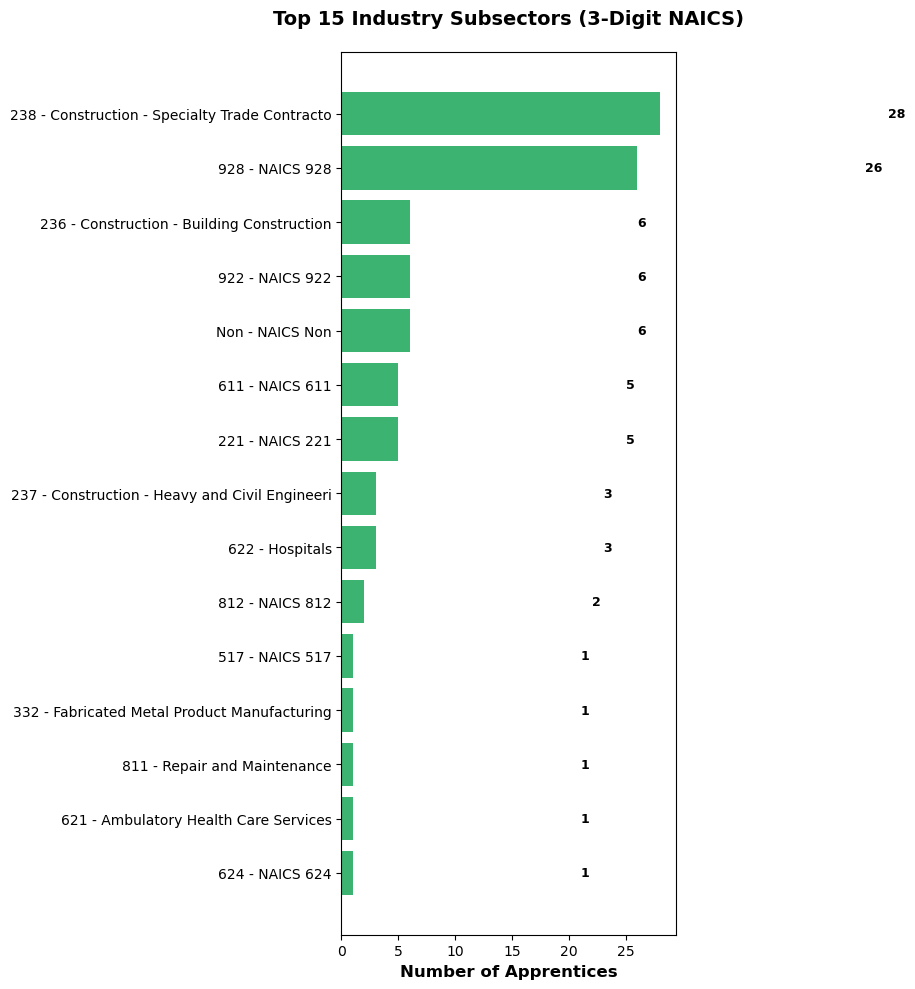

\nTop 15 Subsectors:
624 - NAICS 624                                               1 (  1.0%)


In [29]:

data['naics_cd'] = data['naics_cd'].astype(str)
data['naics_3digit'] = data['naics_cd'].str[:3]

subsector_counts = data['naics_3digit'].value_counts().head(15)
fig4, ax4 = plt.subplots(figsize=(14, 10))
    
bars = ax4.barh(range(len(subsector_counts)), subsector_counts.values, color='mediumseagreen')
ax4.set_yticks(range(len(subsector_counts)))
    
    
labels = []
for code in subsector_counts.index:
        name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
        labels.append(f"{code} - {name[:40]}")
    
ax4.set_yticklabels(labels, fontsize=10)
ax4.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
ax4.set_title('Top 15 Industry Subsectors (3-Digit NAICS)', 
                  fontsize=14, fontweight='bold', pad=20)
ax4.invert_yaxis()
    
    # Add value labels
for i, (bar, val) in enumerate(zip(bars, subsector_counts.values)):
        ax4.text(val + 20, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
    
plt.tight_layout()
plt.savefig('naics_subsectors.png', dpi=300, bbox_inches='tight')
print("✓ Saved: naics_subsectors.png")
plt.show()
    
print("\\nTop 15 Subsectors:")
print("="*60)
for code, count in subsector_counts.items():
        name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
        pct = (count / len(data)) * 100
print(f"{code} - {name:50s} {count:6,d} ({pct:5.1f}%)")


CREATING UNION ANALYSIS VISUALIZATIONS
✓ Saved: union_analysis.png


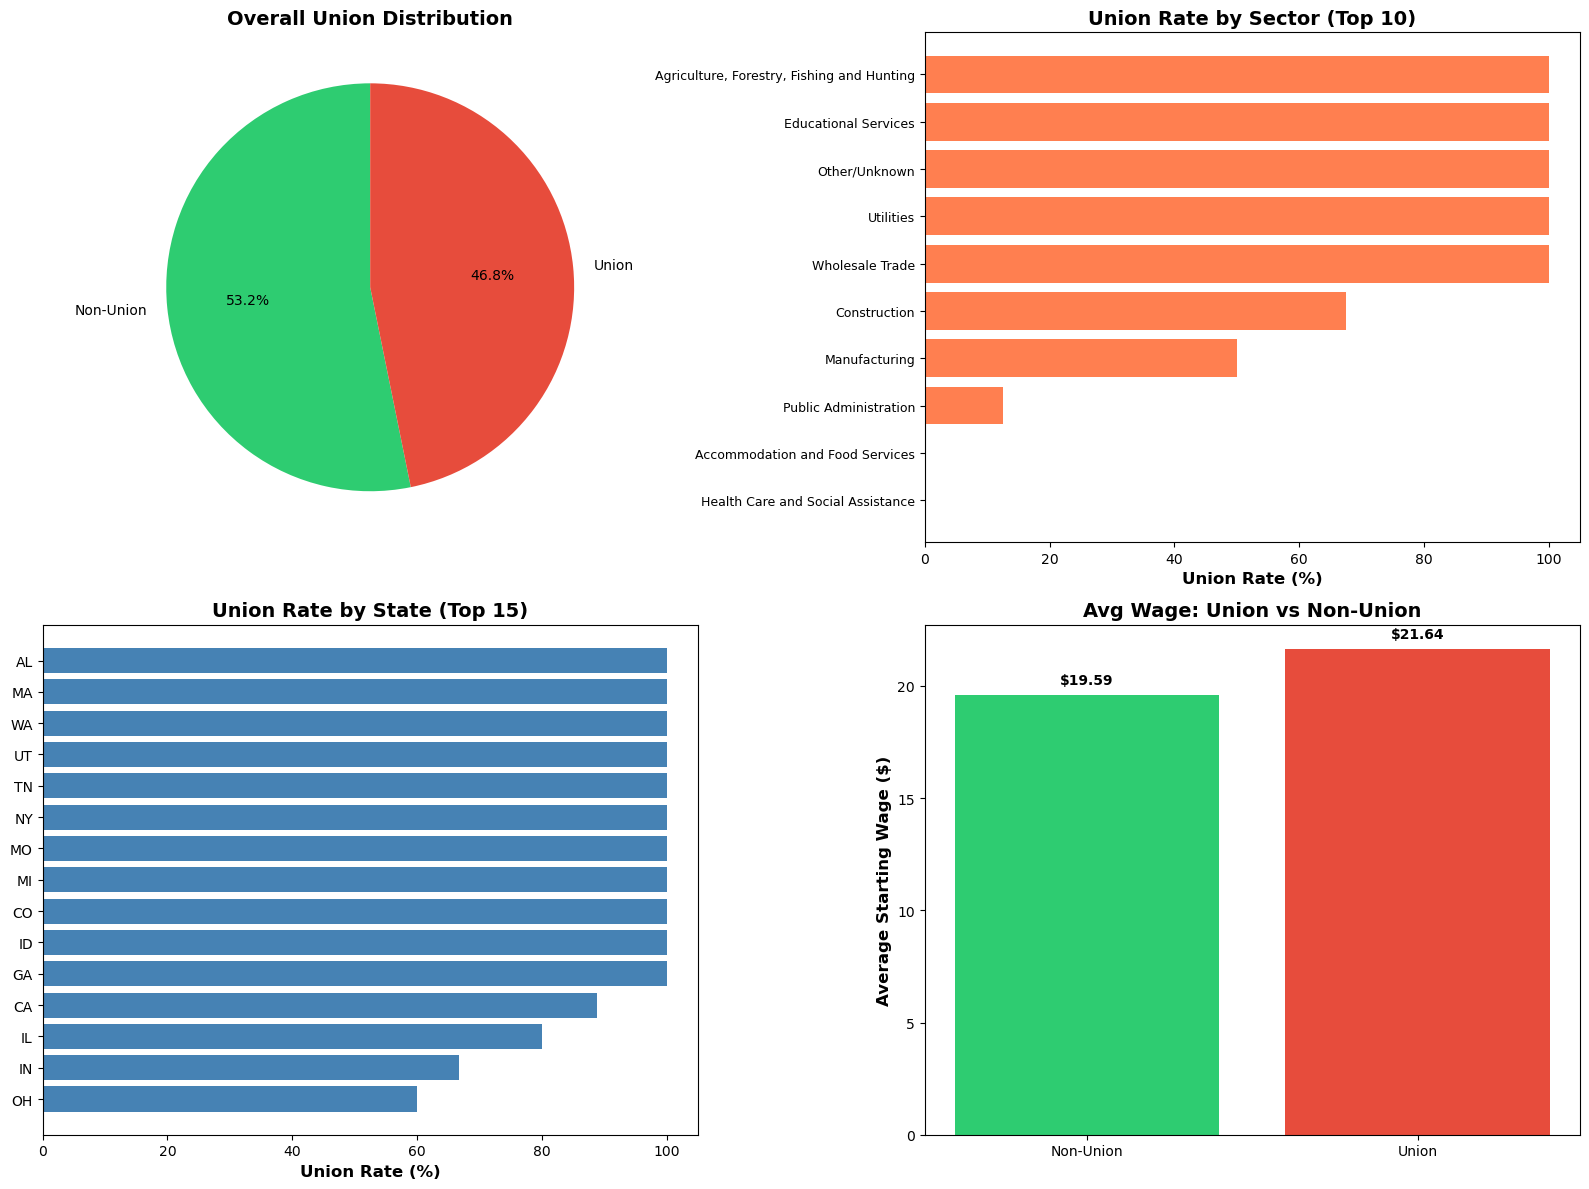

In [43]:
def create_union_visualizations(df):
    """Create union-specific charts"""
    
    print("\n" + "="*70)
    print("CREATING UNION ANALYSIS VISUALIZATIONS")
    print("="*70)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Chart 1: Overall union distribution
    union_counts = df['union_y_n'].map({1: 'Union', 0: 'Non-Union'}).value_counts()
    axes[0, 0].pie(union_counts.values, labels=union_counts.index, autopct='%1.1f%%',
                    colors=['#2ecc71', '#e74c3c'], startangle=90)
    axes[0, 0].set_title('Overall Union Distribution', fontsize=14, fontweight='bold')
    
    # Chart 2: Union rate by sector
    sector_union = df.groupby('sector')['union_y_n'].mean().sort_values(ascending=False).head(10) * 100
    axes[0, 1].barh(range(len(sector_union)), sector_union.values, color='coral')
    axes[0, 1].set_yticks(range(len(sector_union)))
    axes[0, 1].set_yticklabels(sector_union.index, fontsize=9)
    axes[0, 1].set_xlabel('Union Rate (%)', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Union Rate by Sector (Top 10)', fontsize=14, fontweight='bold')
    axes[0, 1].invert_yaxis()
    
    # Chart 3: Union rate by state
    state_union = df.groupby('state')['union_y_n'].mean().sort_values(ascending=False).head(15) * 100
    axes[1, 0].barh(range(len(state_union)), state_union.values, color='steelblue')
    axes[1, 0].set_yticks(range(len(state_union)))
    axes[1, 0].set_yticklabels(state_union.index)
    axes[1, 0].set_xlabel('Union Rate (%)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Union Rate by State (Top 15)', fontsize=14, fontweight='bold')
    axes[1, 0].invert_yaxis()
    
    # Chart 4: Avg wage union vs non-union
    if 'starting_wage' in df.columns:
        wage_comparison = df.groupby(df['union_y_n'].map({1: 'Union', 0: 'Non-Union'}))['starting_wage'].mean()
        axes[1, 1].bar(wage_comparison.index, wage_comparison.values, color=['#2ecc71', '#e74c3c'])
        axes[1, 1].set_ylabel('Average Starting Wage ($)', fontsize=12, fontweight='bold')
        axes[1, 1].set_title('Avg Wage: Union vs Non-Union', fontsize=14, fontweight='bold')
        
        for i, v in enumerate(wage_comparison.values):
            axes[1, 1].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('union_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: union_analysis.png")
    plt.show()

# Run it
create_union_visualizations(data_clean)


GEOGRAPHIC ANALYSIS

Top 15 States:
----------------------------------------------------------------------
 1. USMAP                      26 ( 26.0%)
 2. CA                         11 ( 11.0%)
 3. NJ                          6 (  6.0%)
 4. OH                          5 (  5.0%)
 5. IL                          5 (  5.0%)
 6. ZA                          5 (  5.0%)
 7. PA                          5 (  5.0%)
 8. TX                          4 (  4.0%)
 9. MO                          4 (  4.0%)
10. IN                          3 (  3.0%)
11. WA                          3 (  3.0%)
12. MI                          2 (  2.0%)
13. NY                          2 (  2.0%)
14. IA                          2 (  2.0%)
15. FL                          2 (  2.0%)

By Region:
----------------------------------------------------------------------
Other                 32 ( 32.0%)
Midwest               22 ( 22.0%)
West                  17 ( 17.0%)
Northeast             16 ( 16.0%)
South                 13 ( 1

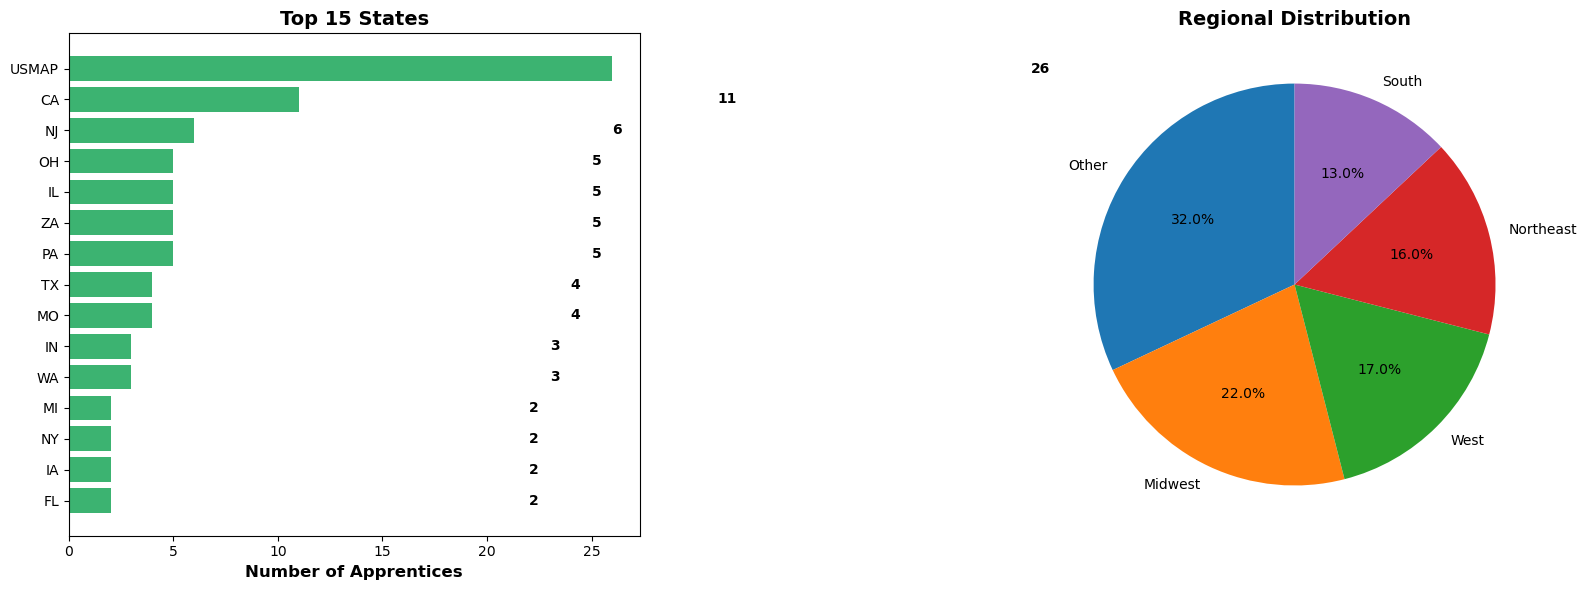

In [44]:
def analyze_geography(df):
    """Geographic analysis by state and region"""
    
    print("\n" + "="*70)
    print("GEOGRAPHIC ANALYSIS")
    print("="*70)
    
    # State counts
    state_counts = df['state'].value_counts()
    
    print("\nTop 15 States:")
    print("-"*70)
    for idx, (state, count) in enumerate(state_counts.head(15).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{idx:2d}. {state:20s} {count:8,d} ({pct:5.1f}%)")
    
    # Regional grouping
    regions = {
        'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
        'Midwest': ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'],
        'South': ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX'],
        'West': ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']
    }
    
    def get_region(state):
        for region, states in regions.items():
            if state in states:
                return region
        return 'Other'
    
    df['region'] = df['state'].apply(get_region)
    region_counts = df['region'].value_counts()
    
    print("\nBy Region:")
    print("-"*70)
    for region, count in region_counts.items():
        pct = (count / len(df)) * 100
        print(f"{region:15s} {count:8,d} ({pct:5.1f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Chart 1: Top states
    top_15 = state_counts.head(15)
    axes[0].barh(range(len(top_15)), top_15.values, color='mediumseagreen')
    axes[0].set_yticks(range(len(top_15)))
    axes[0].set_yticklabels(top_15.index)
    axes[0].set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
    axes[0].set_title('Top 15 States', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    
    for i, v in enumerate(top_15.values):
        axes[0].text(v + 20, i, f'{v:,}', va='center', fontweight='bold')
    
    # Chart 2: Regional pie chart
    axes[1].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Regional Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('geographic_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: geographic_analysis.png")
    plt.show()
    
    return state_counts, region_counts, df

# Run it
state_summary, region_summary, data_clean = analyze_geography(data_clean)

STEP 1: PREPARING DATA
✓ Data prepared!

STEP 2: CREATING SECTOR SUMMARY
✓ sector_summary created!
  Shape: (12, 3)

STEP 3: CREATING SUBSECTOR DATAFRAME
✓ subsector_df created!
  Shape: (20, 4)

STEP 4: CREATING NAICS CODES DATAFRAME
✓ naics_codes created!
  Shape: (30, 4)

STEP 5: CREATING SECTOR COMPARISON
✓ comparison_df created!
  Shape: (10, 6)

STEP 6: VERIFICATION
✓ data_clean exists (100 records)
✓ sector_summary exists (12 records)
✓ subsector_df exists (20 records)
✓ naics_codes exists (30 records)
✓ comparison_df exists (10 records)

STEP 7: EXPORTING TO EXCEL
✓ Excel file created: naics_industry_analysis.xlsx

STEP 8: CREATING VISUALIZATIONS
✓ Saved: sector_chart.png


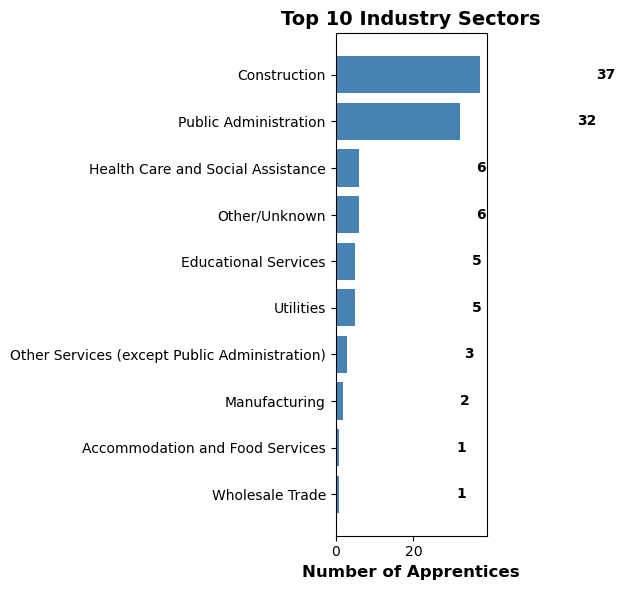

✓ Saved: subsector_chart.png


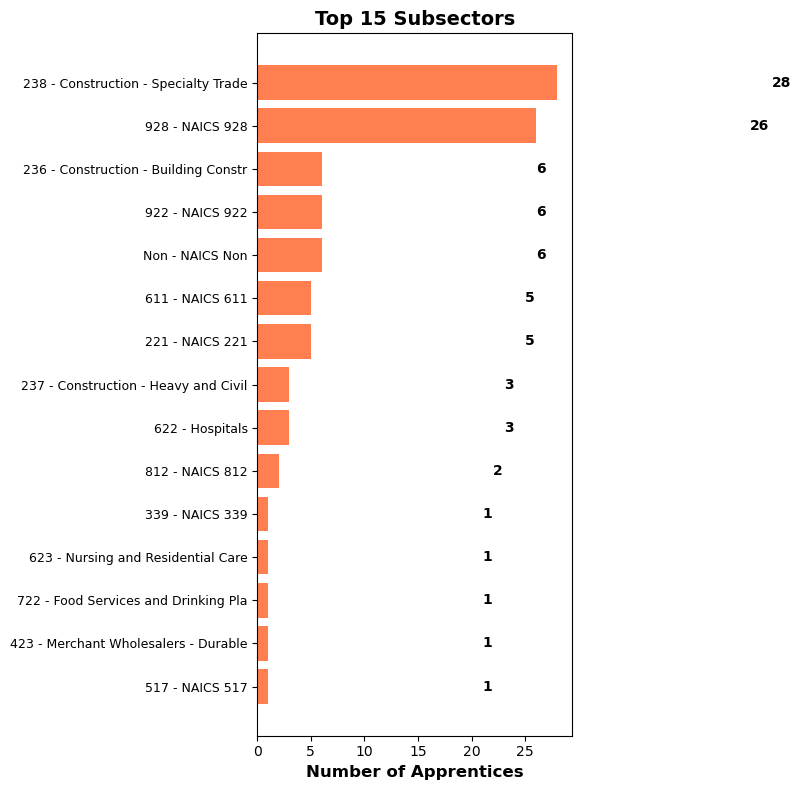


FILES CREATED
✓ naics_industry_analysis.xlsx
✓ sector_chart.png
✓ subsector_chart.png

ANALYSIS COMPLETE!


In [45]:

# ============================================================================
# STEP 1: PREPARE DATA (if not already done)
# ============================================================================

print("="*70)
print("STEP 1: PREPARING DATA")
print("="*70)

# Ensure NAICS columns exist
if 'naics_2digit' not in data_clean.columns:
    data_clean['naics_cd'] = data_clean['naics_cd'].astype(str)
    data_clean['naics_2digit'] = data_clean['naics_cd'].str[:2]
    data_clean['naics_3digit'] = data_clean['naics_cd'].str[:3]
    
    # NAICS mappings
    NAICS_SECTORS = {
        '23': 'Construction',
        '31': 'Manufacturing', '32': 'Manufacturing', '33': 'Manufacturing',
        '42': 'Wholesale Trade',
        '44': 'Retail Trade', '45': 'Retail Trade',
        '48': 'Transportation and Warehousing', '49': 'Transportation and Warehousing',
        '62': 'Health Care and Social Assistance',
        '72': 'Accommodation and Food Services',
        '81': 'Other Services',
        '92': 'Public Administration'
    }
    
    NAICS_SUBSECTORS = {
        '238': 'Construction - Specialty Trade Contractors',
        '236': 'Construction - Building Construction',
        '237': 'Construction - Heavy and Civil Engineering',
        '722': 'Food Services and Drinking Places',
        '623': 'Nursing and Residential Care',
        '332': 'Fabricated Metal Product Manufacturing',
        '423': 'Merchant Wholesalers - Durable Goods',
        '811': 'Repair and Maintenance'
    }
    
    data_clean['sector'] = data_clean['naics_2digit'].map(NAICS_SECTORS)
    data_clean['sector'] = data_clean['sector'].fillna('Other/Unknown')
    data_clean['subsector'] = data_clean['naics_3digit'].map(NAICS_SUBSECTORS)

print("✓ Data prepared!")

# ============================================================================
# STEP 2: CREATE sector_summary
# ============================================================================

print("\n" + "="*70)
print("STEP 2: CREATING SECTOR SUMMARY")
print("="*70)

sector_counts = data_clean['sector'].value_counts().sort_values(ascending=False)
sector_pct = (sector_counts / len(data_clean) * 100).round(2)

sector_summary = pd.DataFrame({
    'Sector': sector_counts.index,
    'Apprentices': sector_counts.values,
    'Percentage': sector_pct.values
})

print("✓ sector_summary created!")
print(f"  Shape: {sector_summary.shape}")

# ============================================================================
# STEP 3: CREATE subsector_df
# ============================================================================

print("\n" + "="*70)
print("STEP 3: CREATING SUBSECTOR DATAFRAME")
print("="*70)

subsector_counts = data_clean['naics_3digit'].value_counts().sort_values(ascending=False).head(20)

subsector_data = []
for code, count in subsector_counts.items():
    name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
    pct = (count / len(data_clean) * 100)
    subsector_data.append({
        'NAICS Code': code,
        'Subsector': name,
        'Apprentices': count,
        'Percentage': round(pct, 2)
    })

subsector_df = pd.DataFrame(subsector_data)

print("✓ subsector_df created!")
print(f"  Shape: {subsector_df.shape}")

# ============================================================================
# STEP 4: CREATE naics_codes
# ============================================================================

print("\n" + "="*70)
print("STEP 4: CREATING NAICS CODES DATAFRAME")
print("="*70)

naics_codes = data_clean.groupby(['naics_cd', 'industry', 'occupation']).size().reset_index(name='count')
naics_codes = naics_codes.sort_values('count', ascending=False).head(30)

print("✓ naics_codes created!")
print(f"  Shape: {naics_codes.shape}")

# ============================================================================
# STEP 5: CREATE comparison_df
# ============================================================================

print("\n" + "="*70)
print("STEP 5: CREATING SECTOR COMPARISON")
print("="*70)

analysis_data = []

for sector in data_clean['sector'].value_counts().head(10).index:
    sector_df = data_clean[data_clean['sector'] == sector]
    
    analysis_data.append({
        'Sector': sector,
        'Total Apprentices': len(sector_df),
        'Union Rate (%)': round(sector_df['union_y_n'].mean() * 100, 1) if 'union_y_n' in data_clean.columns else None,
        'Avg Start Wage ($)': round(sector_df['starting_wage'].mean(), 2) if 'starting_wage' in data_clean.columns else None,
        '% Female': round((sector_df['gender'] == 'Female').sum() / len(sector_df) * 100, 1) if 'gender' in data_clean.columns else None,
        'Unique Occupations': sector_df['occupation'].nunique() if 'occupation' in data_clean.columns else None
    })

comparison_df = pd.DataFrame(analysis_data)

print("✓ comparison_df created!")
print(f"  Shape: {comparison_df.shape}")

# ============================================================================
# STEP 6: VERIFY ALL VARIABLES EXIST
# ============================================================================

print("\n" + "="*70)
print("STEP 6: VERIFICATION")
print("="*70)

required_vars = {
    'data_clean': data_clean,
    'sector_summary': sector_summary,
    'subsector_df': subsector_df,
    'naics_codes': naics_codes,
    'comparison_df': comparison_df
}

all_exist = True
for var_name, var_value in required_vars.items():
    if var_value is not None and len(var_value) > 0:
        print(f"✓ {var_name} exists ({len(var_value)} records)")
    else:
        print(f"✗ {var_name} is missing or empty")
        all_exist = False

# ============================================================================
# STEP 7: EXPORT TO EXCEL (only if all variables exist)
# ============================================================================

if all_exist:
    print("\n" + "="*70)
    print("STEP 7: EXPORTING TO EXCEL")
    print("="*70)
    
    filename = 'naics_industry_analysis.xlsx'
    
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        # Executive Summary
        summary_data = {
            'Metric': [
                'Total Apprentices Analyzed',
                'Top Sector',
                'Top Sector Count',
                'Top Sector Share (%)',
                'Number of Unique Sectors',
                'Number of Unique Subsectors',
                'Number of Unique NAICS Codes',
                'Top 3 Sectors Concentration (%)'
            ],
            'Value': [
                f"{len(data_clean):,}",
                sector_summary['Sector'].iloc[0],
                f"{sector_summary['Apprentices'].iloc[0]:,}",
                f"{sector_summary['Percentage'].iloc[0]:.1f}%",
                data_clean['sector'].nunique(),
                data_clean['naics_3digit'].nunique(),
                data_clean['naics_cd'].nunique(),
                f"{sector_summary['Percentage'].head(3).sum():.1f}%"
            ]
        }
        pd.DataFrame(summary_data).to_excel(writer, sheet_name='Executive Summary', index=False)
        
        # Other sheets
        sector_summary.to_excel(writer, sheet_name='Sector Analysis', index=False)
        subsector_df.to_excel(writer, sheet_name='Subsector Analysis', index=False)
        naics_codes.to_excel(writer, sheet_name='Top NAICS Codes', index=False)
        comparison_df.to_excel(writer, sheet_name='Sector Comparison', index=False)
        
        # Data sample
        df_export = data_clean[[
            'apprentice_id', 'naics_cd', 'naics_2digit', 'naics_3digit',
            'sector', 'industry', 'occupation'
        ]].head(5000)
        df_export.to_excel(writer, sheet_name='Data Sample', index=False)
    
    print(f"✓ Excel file created: {filename}")

    # ============================================================================
    # STEP 8: CREATE VISUALIZATIONS
    # ============================================================================
    
    print("\n" + "="*70)
    print("STEP 8: CREATING VISUALIZATIONS")
    print("="*70)
    
    # Chart 1: Sectors
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    top_10 = sector_summary.head(10)
    ax1.barh(top_10['Sector'], top_10['Apprentices'], color='steelblue')
    ax1.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
    ax1.set_title('Top 10 Industry Sectors', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    for i, v in enumerate(top_10['Apprentices']):
        ax1.text(v + 30, i, f'{v:,}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('sector_chart.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: sector_chart.png")
    plt.show()
    
    # Chart 2: Subsectors
    fig2, ax2 = plt.subplots(figsize=(12, 8))
    top_15 = subsector_df.head(15)
    ax2.barh(range(len(top_15)), top_15['Apprentices'], color='coral')
    ax2.set_yticks(range(len(top_15)))
    ax2.set_yticklabels([f"{row['NAICS Code']} - {row['Subsector'][:30]}" 
                         for _, row in top_15.iterrows()], fontsize=9)
    ax2.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
    ax2.set_title('Top 15 Subsectors', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    for i, v in enumerate(top_15['Apprentices']):
        ax2.text(v + 20, i, f'{v:,}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('subsector_chart.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: subsector_chart.png")
    plt.show()
    
    # ============================================================================
    # STEP 9: CHECK FILES
    # ============================================================================
    
    print("\n" + "="*70)
    print("FILES CREATED")
    print("="*70)
    
    files = [
        'naics_industry_analysis.xlsx',
        'sector_chart.png',
        'subsector_chart.png'
    ]
    
    for file in files:
        if os.path.exists(file):
            print(f"✓ {file}")
        else:
            print(f"✗ {file} not found")
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE!")
    print("="*70)

else:
    print("\n✗ Cannot proceed - some required variables are missing")
    


               NAICS INDUSTRY SECTOR ANALYSIS
                  Apprenticeship Participation
PREPARING NAICS CLASSIFICATIONS

Total records: 100
Unique NAICS codes: 34
Unique sectors: 12

SECTOR ANALYSIS (2-DIGIT NAICS)

Top 10 Sectors:
----------------------------------------------------------------------
Construction                                            37 ( 37.0%)
Public Administration                                   32 ( 32.0%)
Health Care and Social Assistance                        6 (  6.0%)
Other/Unknown                                            6 (  6.0%)
Educational Services                                     5 (  5.0%)
Utilities                                                5 (  5.0%)
Other Services (except Public Administration)            3 (  3.0%)
Manufacturing                                            2 (  2.0%)
Accommodation and Food Services                          1 (  1.0%)
Wholesale Trade                                          1 (  1.0%)

SUBSECTOR 

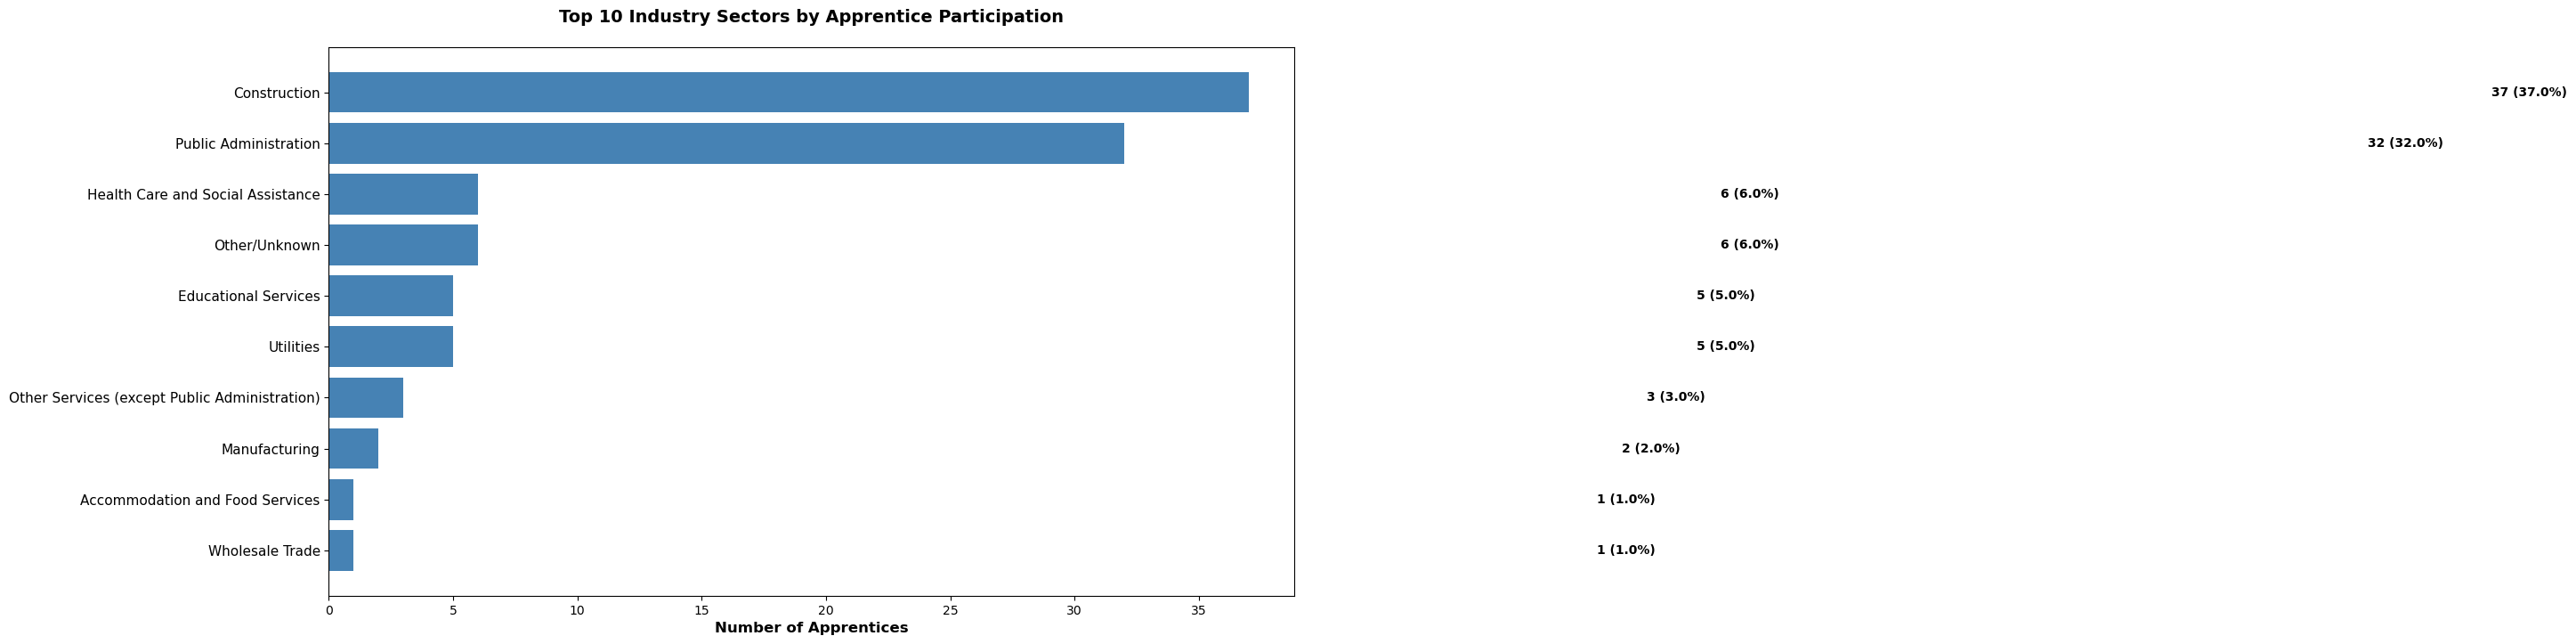

✓ Saved: naics_sector_pie.png


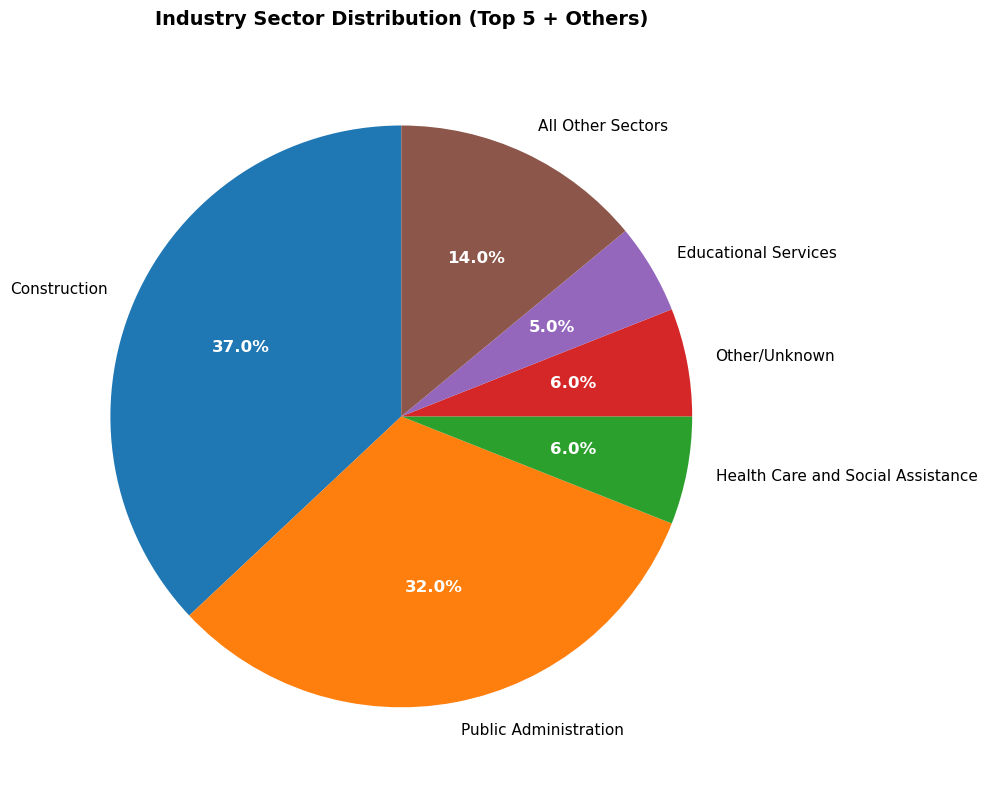

✓ Saved: naics_subsectors.png


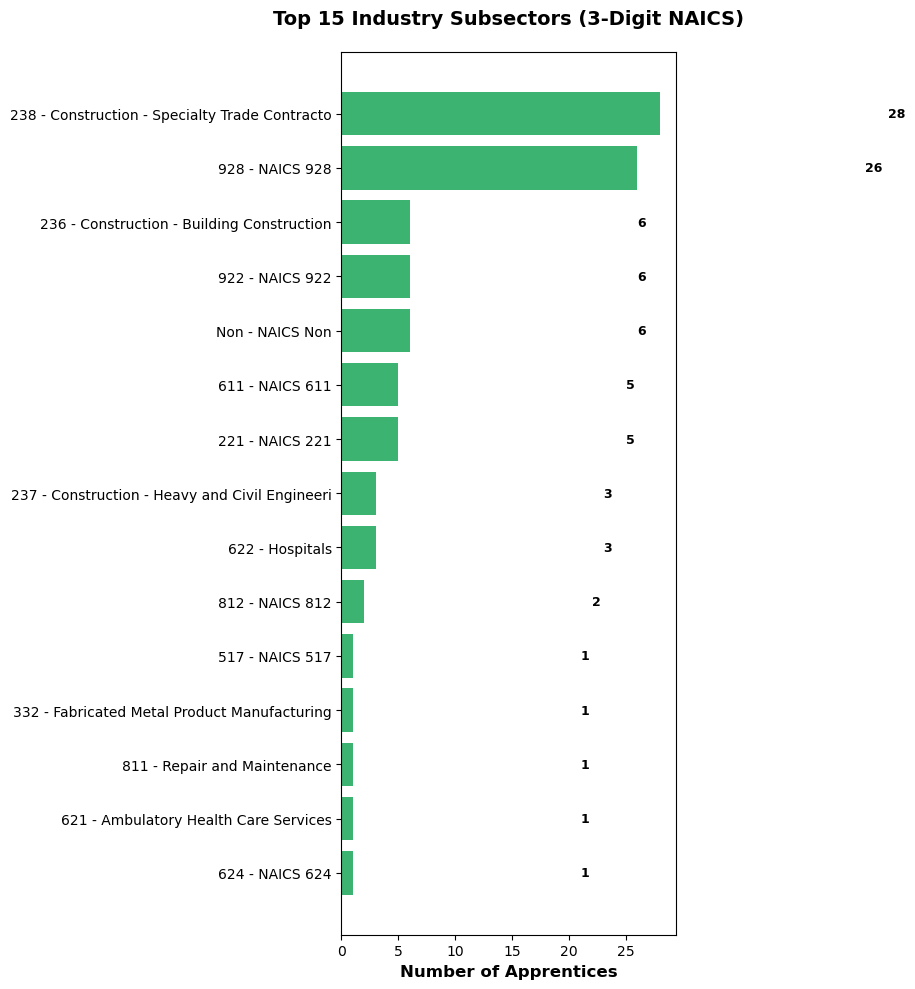


ALL VISUALIZATIONS COMPLETE

EXPORTING TO EXCEL
✓ Excel file created: naics_industry_analysis.xlsx

ANALYSIS COMPLETE

  • Top sector: Construction
  • Count: 37 (37.0%)
  • Unique sectors: 12



In [46]:

NAICS_SECTORS = {
    '11': 'Agriculture, Forestry, Fishing and Hunting',
    '21': 'Mining, Quarrying, and Oil and Gas Extraction',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing', '32': 'Manufacturing', '33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44': 'Retail Trade', '45': 'Retail Trade',
    '48': 'Transportation and Warehousing', '49': 'Transportation and Warehousing',
    '51': 'Information',
    '52': 'Finance and Insurance',
    '53': 'Real Estate and Rental and Leasing',
    '54': 'Professional, Scientific, and Technical Services',
    '55': 'Management of Companies and Enterprises',
    '56': 'Administrative and Support Services',
    '61': 'Educational Services',
    '62': 'Health Care and Social Assistance',
    '71': 'Arts, Entertainment, and Recreation',
    '72': 'Accommodation and Food Services',
    '81': 'Other Services (except Public Administration)',
    '92': 'Public Administration'
}

NAICS_SUBSECTORS = {
    '236': 'Construction - Building Construction',
    '237': 'Construction - Heavy and Civil Engineering',
    '238': 'Construction - Specialty Trade Contractors',
    '311': 'Food Manufacturing',
    '323': 'Printing and Related Support',
    '326': 'Plastics and Rubber Products',
    '331': 'Primary Metal Manufacturing',
    '332': 'Fabricated Metal Product Manufacturing',
    '333': 'Machinery Manufacturing',
    '335': 'Electrical Equipment Manufacturing',
    '336': 'Transportation Equipment Manufacturing',
    '423': 'Merchant Wholesalers - Durable Goods',
    '441': 'Motor Vehicle and Parts Dealers',
    '484': 'Truck Transportation',
    '621': 'Ambulatory Health Care Services',
    '622': 'Hospitals',
    '623': 'Nursing and Residential Care',
    '722': 'Food Services and Drinking Places',
    '811': 'Repair and Maintenance'
}

# ============================================================================
# FUNCTION 1: PREPARE DATA
# ============================================================================

def prepare_naics_data(df):
    """Add NAICS sector and subsector classifications"""
    
    print("="*70)
    print("PREPARING NAICS CLASSIFICATIONS")
    print("="*70)
    
    df['naics_cd'] = df['naics_cd'].astype(str)
    df['naics_2digit'] = df['naics_cd'].str[:2]
    df['naics_3digit'] = df['naics_cd'].str[:3]
    
    df['sector'] = df['naics_2digit'].map(NAICS_SECTORS)
    df['sector'] = df['sector'].fillna('Other/Unknown')
    
    df['subsector'] = df['naics_3digit'].map(NAICS_SUBSECTORS)
    
    print(f"\nTotal records: {len(df):,}")
    print(f"Unique NAICS codes: {df['naics_cd'].nunique():,}")
    print(f"Unique sectors: {df['sector'].nunique():,}")
    
    return df

# ============================================================================
# FUNCTION 2: SECTOR ANALYSIS
# ============================================================================

def analyze_by_sector(df):
    """Analyze by major sector"""
    
    print("\n" + "="*70)
    print("SECTOR ANALYSIS (2-DIGIT NAICS)")
    print("="*70)
    
    sector_counts = df['sector'].value_counts().sort_values(ascending=False)
    sector_pct = (sector_counts / len(df) * 100).round(2)
    
    sector_summary = pd.DataFrame({
        'Sector': sector_counts.index,
        'Apprentices': sector_counts.values,
        'Percentage': sector_pct.values
    })
    
    print("\nTop 10 Sectors:")
    print("-"*70)
    for idx, row in sector_summary.head(10).iterrows():
        print(f"{row['Sector']:50s} {row['Apprentices']:7,d} ({row['Percentage']:5.1f}%)")
    
    # Sector stats
    sector_stats = None
    if 'union_y_n' in df.columns:
        sector_stats = df.groupby('sector').agg({
            'apprentice_id': 'count',
            'union_y_n': 'mean',
            'starting_wage': 'mean' if 'starting_wage' in df.columns else 'count'
        }).round(2)
        sector_stats.columns = ['Count', 'Union Rate', 'Avg Start Wage']
        sector_stats = sector_stats.sort_values('Count', ascending=False)
    
    return sector_summary, sector_stats

# ============================================================================
# FUNCTION 3: SUBSECTOR ANALYSIS
# ============================================================================

def analyze_by_subsector(df):
    """Analyze by subsector"""
    
    print("\n" + "="*70)
    print("SUBSECTOR ANALYSIS (3-DIGIT NAICS)")
    print("="*70)
    
    subsector_counts = df['naics_3digit'].value_counts().sort_values(ascending=False).head(20)
    
    subsector_data = []
    for code, count in subsector_counts.items():
        name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
        pct = (count / len(df) * 100)
        subsector_data.append({
            'NAICS Code': code,
            'Subsector': name,
            'Apprentices': count,
            'Percentage': round(pct, 2)
        })
    
    subsector_df = pd.DataFrame(subsector_data)
    
    print("\nTop 20 Subsectors:")
    print("-"*70)
    print(subsector_df.head(10).to_string(index=False))
    
    return subsector_df

# ============================================================================
# FUNCTION 4: SPECIFIC NAICS CODES
# ============================================================================

def analyze_specific_naics_codes(df, top_n=30):
    """Analyze specific NAICS codes"""
    
    print("\n" + "="*70)
    print(f"TOP {top_n} SPECIFIC NAICS CODES")
    print("="*70)
    
    naics_counts = df.groupby(['naics_cd', 'industry', 'occupation']).size().reset_index(name='count')
    naics_counts = naics_counts.sort_values('count', ascending=False).head(top_n)
    
    print(f"\nTop 10 NAICS Codes:")
    print("-"*70)
    for idx, row in naics_counts.head(10).iterrows():
        print(f"\nNAICS {row['naics_cd']}:")
        print(f"  Industry: {row['industry']}")
        print(f"  Occupation: {row['occupation']}")
        print(f"  Apprentices: {row['count']:,}")
    
    return naics_counts

# ============================================================================
# FUNCTION 5: CROSS-SECTOR ANALYSIS
# ============================================================================

def cross_sector_analysis(df):
    """Cross-sector comparison"""
    
    print("\n" + "="*70)
    print("CROSS-SECTOR COMPARATIVE ANALYSIS")
    print("="*70)
    
    analysis_data = []
    
    for sector in df['sector'].value_counts().head(10).index:
        sector_df = df[df['sector'] == sector]
        
        analysis_data.append({
            'Sector': sector,
            'Total Apprentices': len(sector_df),
            'Union Rate (%)': round(sector_df['union_y_n'].mean() * 100, 1) if 'union_y_n' in df.columns else None,
            'Avg Start Wage ($)': round(sector_df['starting_wage'].mean(), 2) if 'starting_wage' in df.columns else None,
            '% Female': round((sector_df['gender'] == 'Female').sum() / len(sector_df) * 100, 1) if 'gender' in df.columns else None,
            'Unique Occupations': sector_df['occupation'].nunique() if 'occupation' in df.columns else None
        })
    
    comparison_df = pd.DataFrame(analysis_data)
    
    print("\nSector Comparison (Top 10):")
    print("-"*70)
    print(comparison_df.to_string(index=False))
    
    return comparison_df

# ============================================================================
# FUNCTION 6: CREATE VISUALIZATIONS
# ============================================================================

def create_naics_visualizations(df, sector_summary, sector_stats=None):
    """Create all visualizations"""
    
    print("\n" + "="*70)
    print("CREATING VISUALIZATIONS")
    print("="*70)
    
    # Chart 1: Top Sectors
    fig1, ax1 = plt.subplots(figsize=(14, 8))
    top_10 = sector_summary.head(10)
    
    bars = ax1.barh(range(len(top_10)), top_10['Apprentices'], color='steelblue')
    ax1.set_yticks(range(len(top_10)))
    ax1.set_yticklabels(top_10['Sector'], fontsize=11)
    ax1.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
    ax1.set_title('Top 10 Industry Sectors by Apprentice Participation', 
                  fontsize=14, fontweight='bold', pad=20)
    ax1.invert_yaxis()
    
    for i, (val, pct) in enumerate(zip(top_10['Apprentices'], top_10['Percentage'])):
        ax1.text(val + 50, i, f'{val:,} ({pct:.1f}%)', 
                va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('naics_top_sectors.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: naics_top_sectors.png")
    plt.show()
    
    # Chart 2: Pie Chart
    fig2, ax2 = plt.subplots(figsize=(12, 8))
    
    top_5 = sector_summary.head(5)
    other_count = sector_summary['Apprentices'][5:].sum()
    
    pie_data = list(top_5['Apprentices']) + [other_count]
    pie_labels = list(top_5['Sector']) + ['All Other Sectors']
    
    wedges, texts, autotexts = ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                        startangle=90, textprops={'fontsize': 11})
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    
    ax2.set_title('Industry Sector Distribution (Top 5 + Others)', 
                  fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('naics_sector_pie.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: naics_sector_pie.png")
    plt.show()
    
    # Chart 3: Subsectors
    subsector_counts = df['naics_3digit'].value_counts().head(15)
    
    fig3, ax3 = plt.subplots(figsize=(14, 10))
    
    bars = ax3.barh(range(len(subsector_counts)), subsector_counts.values, color='mediumseagreen')
    ax3.set_yticks(range(len(subsector_counts)))
    
    labels = []
    for code in subsector_counts.index:
        name = NAICS_SUBSECTORS.get(code, f"NAICS {code}")
        labels.append(f"{code} - {name[:40]}")
    
    ax3.set_yticklabels(labels, fontsize=10)
    ax3.set_xlabel('Number of Apprentices', fontsize=12, fontweight='bold')
    ax3.set_title('Top 15 Industry Subsectors (3-Digit NAICS)', 
                  fontsize=14, fontweight='bold', pad=20)
    ax3.invert_yaxis()
    
    for i, val in enumerate(subsector_counts.values):
        ax3.text(val + 20, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('naics_subsectors.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: naics_subsectors.png")
    plt.show()
    
    print("\n" + "="*70)
    print("ALL VISUALIZATIONS COMPLETE")
    print("="*70)

# ============================================================================
# FUNCTION 7: EXPORT TO EXCEL
# ============================================================================

def export_naics_analysis(df, sector_summary, subsector_df, naics_codes, comparison_df):
    """Export to Excel"""
    
    filename = 'naics_industry_analysis.xlsx'
    
    print("\n" + "="*70)
    print("EXPORTING TO EXCEL")
    print("="*70)
    
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        summary_data = {
            'Metric': ['Total Apprentices', 'Top Sector', 'Top Sector Count', 'Unique Sectors'],
            'Value': [
                f"{len(df):,}",
                sector_summary['Sector'].iloc[0],
                f"{sector_summary['Apprentices'].iloc[0]:,}",
                df['sector'].nunique()
            ]
        }
        pd.DataFrame(summary_data).to_excel(writer, sheet_name='Summary', index=False)
        sector_summary.to_excel(writer, sheet_name='Sectors', index=False)
        subsector_df.to_excel(writer, sheet_name='Subsectors', index=False)
        naics_codes.to_excel(writer, sheet_name='NAICS Codes', index=False)
        comparison_df.to_excel(writer, sheet_name='Comparison', index=False)
    
    print(f"✓ Excel file created: {filename}")

# ============================================================================
# FUNCTION 8: RUN COMPLETE ANALYSIS
# ============================================================================

def run_naics_analysis(df):
    """Run complete analysis"""
    
    print("\n" + "="*70)
    print(" "*15 + "NAICS INDUSTRY SECTOR ANALYSIS")
    print(" "*18 + "Apprenticeship Participation")
    print("="*70)
    
    df = prepare_naics_data(df)
    sector_summary, sector_stats = analyze_by_sector(df)
    subsector_df = analyze_by_subsector(df)
    naics_codes = analyze_specific_naics_codes(df, top_n=30)
    comparison_df = cross_sector_analysis(df)
    create_naics_visualizations(df, sector_summary, sector_stats)
    export_naics_analysis(df, sector_summary, subsector_df, naics_codes, comparison_df)
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print("="*70)
    print(f"\n  • Top sector: {sector_summary['Sector'].iloc[0]}")
    print(f"  • Count: {sector_summary['Apprentices'].iloc[0]:,} ({sector_summary['Percentage'].iloc[0]:.1f}%)")
    print(f"  • Unique sectors: {df['sector'].nunique()}")
    print("\n" + "="*70)
    
    return df, sector_summary, comparison_df

# ============================================================================
# RUN IT!
# ============================================================================

df_analyzed, sector_summary, comparison = run_naics_analysis(data_clean)

In [47]:
data['naics_cd'] = data['naics_cd'].astype(str)
data['naics_2digit'] = data['naics_cd'].str[:2]  # Sector
data['naics_3digit'] = data['naics_cd'].str[:3]  # Subsector
data['naics_4digit'] = data['naics_cd'].str[:4]  # Industry Group

print("✓ NAICS columns created!")
print(f"  Unique 2-digit sectors: {data['naics_2digit'].nunique()}")
print(f"  Unique 3-digit subsectors: {data['naics_3digit'].nunique()}")
print(f"  Unique full NAICS codes: {data['naics_cd'].nunique()}")

✓ NAICS columns created!
  Unique 2-digit sectors: 12
  Unique 3-digit subsectors: 20
  Unique full NAICS codes: 34
